IMPORTS

In [24]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transform
import matplotlib.pyplot as plt
import pandas as pd
import pickle

INPUTS

In [25]:
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
inputsize = 784
numclasses=10
numepochs=5
batchsize=100
learningrate=0.001

DATASET LOADING

In [26]:
train_dataset=torchvision.datasets.FashionMNIST(root='./data', train=True, transform=transform.ToTensor(), download=True)
test_dataset=torchvision.datasets.FashionMNIST(root='./data', train=False, transform=transform.ToTensor(), download=True)
train_loader=torch.utils.data.DataLoader(dataset=train_dataset,batch_size=batchsize,shuffle=True)
test_loader=torch.utils.data.DataLoader(dataset=test_dataset,batch_size=batchsize,shuffle=False)


MODEL DEFINITION

In [27]:
class spidernet(nn.Module):
    def __init__(self):

        super().__init__()
        self.l1=nn.Linear(784,16)
        self.relu=nn.ReLU()
        self.left_l2=nn.Linear(16,8)
        self.left_l3=nn.Linear(8,8)

        self.right_l4 = nn.Linear(16, 12)
        self.right_l5 = nn.Linear(12, 8)

        self.output_layer = nn.Linear(16, 10)

    def forward(self,x):
        x=x.view(x.size(0),-1)

        x1 = self.relu(self.l1(x))

        left_out2 = self.relu(self.left_l2(x1))
        left_out3 = self.relu(self.left_l3(left_out2))

        # Skip connection
        left_branch_final = left_out3 + left_out2

        right_out4 = self.relu(self.right_l4(x1))
        right_branch_final = self.relu(self.right_l5(right_out4))

        merged = torch.cat(
            (left_branch_final, right_branch_final),
            dim=1
        )

        out = self.output_layer(merged)

        return out


LOSS FUNCTION AND OPTIMISER

In [28]:
model = spidernet().to(device)

criterion=nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(),lr=learningrate)

train_losses = []
train_accs = []

val_losses=[]
val_accs=[]


ntotalsteps=len(train_loader)


TRAINING LOOP

In [29]:
for epoch in range(numepochs):


    running_loss = 0.0  #for calculating loss during training
    correct=0  #for calculating accuracy during training
    total=0

    model.train()

    for i,(images,labels) in enumerate(train_loader):

     images=images.to(device)
     labels=labels.to(device)

     outputs=model(images)

     loss=criterion(outputs,labels)
     optimizer.zero_grad()

     loss.backward()
     optimizer.step()

     running_loss += loss.item()

     _, predicted = torch.max(outputs, 1)
     total += labels.size(0)
     correct += (predicted == labels).sum().item()



    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)

    train_acc = 100 * correct / total
    train_accs.append(train_acc)


    #VALIDATION
    model.eval()

    val_loss = 0  #for calculating loss during validation
    correct = 0  #for calculating accuracy during validation
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss = val_loss / len(test_loader)
    val_acc = 100 * correct / total

    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}/{numepochs}")
    print(f"Train Loss: {train_losses[epoch]:.4f}")
    print(f"Train Accuracy: {train_accs[epoch]:.2f}%")
    print(f"Validation Loss: {val_losses[epoch]:.4f}")
    print(f"Validation Accuracy: {val_accs[epoch]:.2f}%\n")


Epoch 1/5
Train Loss: 0.7827
Train Accuracy: 72.71%
Validation Loss: 0.5476
Validation Accuracy: 80.77%

Epoch 2/5
Train Loss: 0.4906
Train Accuracy: 83.00%
Validation Loss: 0.5016
Validation Accuracy: 82.87%

Epoch 3/5
Train Loss: 0.4486
Train Accuracy: 84.40%
Validation Loss: 0.4685
Validation Accuracy: 83.64%

Epoch 4/5
Train Loss: 0.4264
Train Accuracy: 85.10%
Validation Loss: 0.4507
Validation Accuracy: 84.29%

Epoch 5/5
Train Loss: 0.4132
Train Accuracy: 85.60%
Validation Loss: 0.4430
Validation Accuracy: 84.78%



PLOTTING LOSS AND ACCURACY

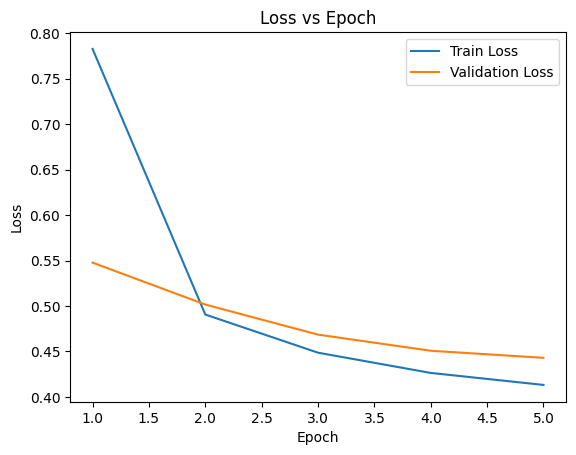

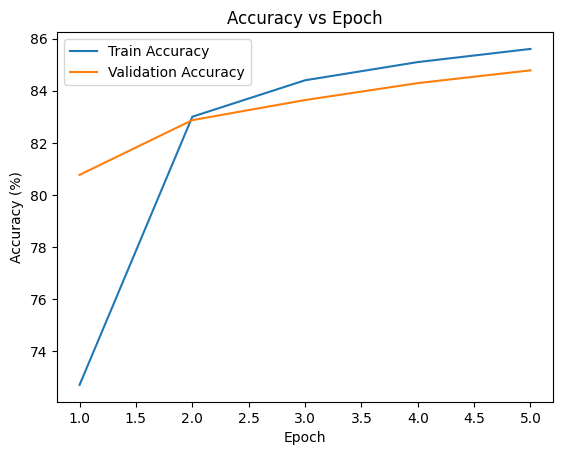

In [30]:
epochs = range(1, numepochs + 1)

plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, val_losses, label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss vs Epoch')
plt.legend()
plt.savefig('loss_plot.png')
plt.show()


plt.plot(epochs, train_accs, label='Train Accuracy')
plt.plot(epochs, val_accs, label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy vs Epoch')
plt.legend()
plt.savefig('accuracy_plot.png')
plt.show()


TEST LOOP

In [31]:
predictions_list=[]

model.eval()
with torch.no_grad():
    ncorrect=0
    nsamples=0
    for images,labels in test_loader:
        images=images.to(device)
        labels=labels.to(device)
        outputs=model(images)

        _,predictions=torch.max(outputs,1)
        predictions_list.extend(predictions.cpu().tolist())

        nsamples+=labels.shape[0]
        ncorrect+=(predictions==labels).sum().item()

    acc=100.0 * ncorrect / nsamples
    print(f'Overall accuracy for test loop={acc}')


Overall accuracy for test loop=84.78


SUBMISSION.CSV

In [32]:
submission = pd.DataFrame({
    'Id' : range(len(predictions_list)),
    'Label' : predictions_list
})

submission.to_csv('submission.csv',index=False)
print("submission.csv created successfully")


submission.csv created successfully


SAVING WEIGHTS

In [33]:
with open('fashion_mnist_weights.pkl', 'wb') as f:
    pickle.dump(model.state_dict(), f)

print("Weights saved! successfully using pickle")

Weights saved! successfully using pickle


In [34]:
torch.save(model.state_dict(), "fashion_mnist_model.pth")